In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm


C:\Users\13min\anaconda3\envs\torchgpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [ ]:
# Define a series of image transformations for data augmentation and normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),             # Resize all images to 128x128 pixels
    transforms.RandomHorizontalFlip(),         # Randomly flip images horizontally (data augmentation)
    transforms.RandomRotation(15),             # Apply random rotations up to 15 degrees (data augmentation)
    transforms.ToTensor(),                     # Convert image to PyTorch tensor (from [0,255] to [0,1])
    transforms.Normalize((0.5,), (0.5,))        # Normalize pixel values to [-1, 1]
])

# Specify the root directory containing the training data
data_dir = "train"

# Load the dataset using ImageFolder, which expects subdirectories for each class
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split the dataset into training (80%) and validation (20%) sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Set the batch size for data loading
batch_size = 64

# Create data loaders to load data in batches and shuffle the training set
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Get class names from the dataset's folder structure
class_names = dataset.classes
num_classes = len(class_names)

# Print the class labels detected
print("📦 Classes:", class_names)



📦 Classes: ['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']


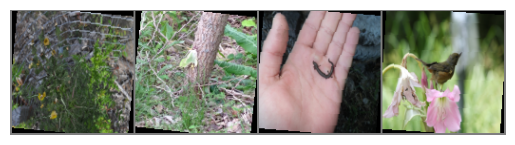

Sample Labels: ['Plantae', 'Insecta', 'Amphibia', 'Aves']


In [ ]:
# Function to display a batch of images from the dataset
def imshow(img):
    img = img / 2 + 0.5                  # Unnormalize the image (originally normalized to [-1, 1])
    npimg = img.numpy()                 # Convert the tensor to a NumPy array
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Change tensor shape from [C, H, W] to [H, W, C] for matplotlib
    plt.axis('off')                     # Hide axes for cleaner image display
    plt.show()                          # Render the image

# Retrieve the first batch of images and labels from the training data loader
images, labels = next(iter(train_loader))

# Display the first 4 images in the batch using the imshow function
imshow(torchvision.utils.make_grid(images[:4]))

# Print the corresponding class labels for the displayed images
print("Sample Labels:", [class_names[label] for label in labels[:4]])


In [ ]:
# Define a custom Convolutional Neural Network (CNN) using PyTorch
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Convolutional feature extractor
        self.conv_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv layer: 3 input channels (RGB) → 32 feature maps
            nn.ReLU(),                                   # Activation function
            nn.MaxPool2d(2),                             # Downsample by a factor of 2 (64x64)
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 64 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2),                             # Downsample again (32x32)
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 128 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2)                              # Final downsample (16x16 output size)
        )

        # Fully connected classifier
        self.fc = nn.Sequential(
            nn.Flatten(),                                # Flatten 128×16×16 output to 1D vector
            nn.Linear(128 * 16 * 16, 256),               # Fully connected layer
            nn.ReLU(),
            nn.Dropout(0.3),                             # Dropout for regularization
            nn.Linear(256, num_classes)                  # Output layer: 10 classes
        )

    # Define the forward pass of the network
    def forward(self, x):
        x = self.conv_stack(x)  # Pass input through convolutional layers
        x = self.fc(x)          # Pass output through fully connected layers
        return x


In [ ]:
# Function to create a ResNet-18 model trained from scratch (no pretrained weights)
def get_resnet18_scratch(num_classes=10):
    # Load ResNet-18 architecture without pretrained weights
    model = models.resnet18(pretrained=False)

    # Replace the original final fully connected layer with a new one for our number of classes
    # Default ResNet-18 ends with a 512-unit layer → replace with (512 → num_classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


In [ ]:
# Function to create a pretrained ResNet-18 model using transfer learning
def get_resnet18_pretrained(num_classes=10):
    # Load ResNet-18 with pretrained weights from ImageNet
    model = models.resnet18(pretrained=True)

    # Freeze all parameters to prevent training the base layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the original fully connected (classifier) layer with a custom head
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),  # Reduce feature dimension to 256
        nn.ReLU(),                             # Activation function
        nn.Dropout(0.4),                       # Dropout to prevent overfitting
        nn.Linear(256, num_classes)            # Output layer matching number of classes
    )

    return model


In [ ]:
# Function to create a pretrained ResNet-50 model using transfer learning
def get_resnet50_pretrained(num_classes=10):
    # Load ResNet-50 with pretrained weights from ImageNet
    model = models.resnet50(pretrained=True)

    # Freeze all parameters to keep the pretrained feature extractor unchanged
    for param in model.parameters():
        param.requires_grad = False

    # Replace the original classification head with a custom classifier
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),  # Intermediate fully connected layer
        nn.ReLU(),                             # Activation function
        nn.Dropout(0.4),                       # Dropout for regularization
        nn.Linear(512, num_classes)            # Final output layer for class predictions
    )

    return model


In [ ]:
# Function to train a model and monitor training and validation accuracy
def train_model(model, name, num_epochs=30):
    # Move model to GPU if available
    model = model.to(device)

    # Define the optimizer (Adam) with only trainable parameters
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=0.001
    )

    # Learning rate scheduler to reduce learning rate after every 5 epochs
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Define the loss function (cross-entropy for multi-class classification)
    criterion = nn.CrossEntropyLoss()

    # Training loop for the specified number of epochs
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss, correct, total = 0.0, 0, 0

        # Iterate through training data in batches
        for inputs, labels in tqdm(train_loader, desc=f"{name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()           # Clear gradients
            outputs = model(inputs)         # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()                 # Backpropagation
            optimizer.step()                # Update weights

            running_loss += loss.item()     # Accumulate batch loss
            _, predicted = torch.max(outputs, 1)  # Get predicted class
            total += labels.size(0)             # Total samples
            correct += (predicted == labels).sum().item()  # Correct predictions

        train_acc = correct / total  # Calculate training accuracy

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = val_correct / val_total  # Calculate validation accuracy

        # Print metrics for this epoch
        print(f"{name} | Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        scheduler.step()  # Step the learning rate scheduler

    return model  # Return the trained model


In [ ]:
# Function to evaluate a trained model on the validation set
def evaluate_model(model, name):
    model.eval()  # Set model to evaluation mode

    correct = 0           # Count of correct predictions overall
    total = 0             # Total number of samples
    class_correct = [0] * num_classes  # Correct predictions per class
    class_total = [0] * num_classes    # Total samples per class

    with torch.no_grad():  # Disable gradient computation for efficiency
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)                # Forward pass
            _, predicted = torch.max(outputs, 1)   # Get predicted class

            total += labels.size(0)                # Update total samples
            correct += (predicted == labels).sum().item()  # Count correct predictions

            # Per-class accuracy tracking
            for i in range(len(labels)):
                class_total[labels[i]] += 1
                if predicted[i] == labels[i]:
                    class_correct[labels[i]] += 1

    # Overall accuracy (Top-1)
    top1_acc = correct / total

    # Average per-class accuracy
    avg_class_acc = sum([
        class_correct[i] / class_total[i] if class_total[i] != 0 else 0
        for i in range(num_classes)
    ]) / num_classes

    # Print evaluation results
    print(f"Evaluation for {name}:")
    print(f"Top-1 Accuracy: {top1_acc:.4f}")
    print(f"Average Accuracy per Class: {avg_class_acc:.4f}")


In [ ]:
# Train and evaluate all four models sequentially

# 1. Train SimpleCNN from scratch
model_simple = train_model(SimpleCNN(num_classes), "SimpleCNN")

# 2. Train ResNet-18 from scratch (no pretrained weights)
model_r18_scratch = train_model(get_resnet18_scratch(num_classes), "ResNet18_Scratch")

# 3. Train ResNet-18 with pretrained weights (transfer learning)
model_r18_pre = train_model(get_resnet18_pretrained(num_classes), "ResNet18_Pretrained")

# 4. Train ResNet-50 with pretrained weights (transfer learning, deeper model)
model_r50_pre = train_model(get_resnet50_pretrained(num_classes), "ResNet50_Pretrained")

# Evaluate all trained models on the validation set

# Evaluate SimpleCNN
evaluate_model(model_simple, "SimpleCNN")

# Evaluate ResNet-18 (Scratch)
evaluate_model(model_r18_scratch, "ResNet18_Scratch")

# Evaluate ResNet-18 (Pretrained)
evaluate_model(model_r18_pre, "ResNet18_Pretrained")

# Evaluate ResNet-50 (Pretrained)
evaluate_model(model_r50_pre, "ResNet50_Pretrained")


SimpleCNN Epoch 1/30: 100%|████████████████████████████████████████████████████████████| 81/81 [00:54<00:00,  1.49it/s]


SimpleCNN | Epoch 1 | Train Acc: 0.2449 | Val Acc: 0.3128


SimpleCNN Epoch 2/30: 100%|████████████████████████████████████████████████████████████| 81/81 [00:46<00:00,  1.73it/s]


SimpleCNN | Epoch 2 | Train Acc: 0.2921 | Val Acc: 0.3035


SimpleCNN Epoch 3/30: 100%|████████████████████████████████████████████████████████████| 81/81 [00:41<00:00,  1.96it/s]


...

ResNet50_Pretrained | Epoch 28 | Train Acc: 0.6877 | Val Acc: 0.6444


ResNet50_Pretrained Epoch 29/30: 100%|█████████████████████████████████████████████████| 81/81 [00:44<00:00,  1.82it/s]


ResNet50_Pretrained | Epoch 29 | Train Acc: 0.6859 | Val Acc: 0.6327


ResNet50_Pretrained Epoch 30/30: 100%|█████████████████████████████████████████████████| 81/81 [00:46<00:00,  1.74it/s]


ResNet50_Pretrained | Epoch 30 | Train Acc: 0.6867 | Val Acc: 0.6241
Evaluation for SimpleCNN:
Top-1 Accuracy: 0.4249
Average Accuracy per Class: 0.3537
Evaluation for ResNet18_Scratch:
Top-1 Accuracy: 0.3564
Average Accuracy per Class: 0.3074
Evaluation for ResNet18_Pretrained:
Top-1 Accuracy: 0.5860
Average Accuracy per Class: 0.5112
Evaluation for ResNet50_Pretrained:
Top-1 Accuracy: 0.6272
Average Accuracy per Class: 0.5764


In [13]:
evaluate_model(model_simple, "SimpleCNN")
evaluate_model(model_r18_scratch, "ResNet18_Scratch")
evaluate_model(model_r18_pre, "ResNet18_Pretrained")
evaluate_model(model_r50_pre, "ResNet50_Pretrained")


Evaluation for SimpleCNN:
Top-1 Accuracy: 0.4202
Average Accuracy per Class: 0.3544
Evaluation for ResNet18_Scratch:
Top-1 Accuracy: 0.3767
Average Accuracy per Class: 0.3240
Evaluation for ResNet18_Pretrained:
Top-1 Accuracy: 0.5969
Average Accuracy per Class: 0.5300
Evaluation for ResNet50_Pretrained:
Top-1 Accuracy: 0.6397
Average Accuracy per Class: 0.5840


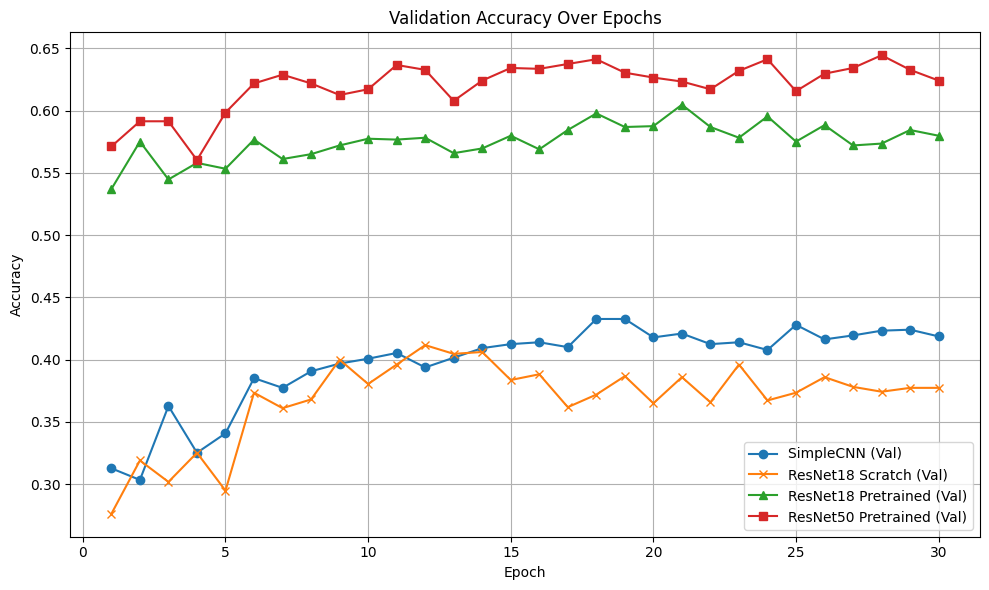

In [14]:
# Manually parsed accuracy values per epoch from the user-provided logs

# SimpleCNN
cnn_train = [0.2449, 0.2921, 0.3172, 0.3394, 0.3542, 0.3820, 0.3982, 0.4120, 0.4174, 0.4359,
             0.4511, 0.4677, 0.4677, 0.4737, 0.4897, 0.5025, 0.5082, 0.5123, 0.5123, 0.5216,
             0.5290, 0.5436, 0.5491, 0.5506, 0.5436, 0.5496, 0.5641, 0.5612, 0.5621, 0.5691]
cnn_val = [0.3128, 0.3035, 0.3628, 0.3253, 0.3409, 0.3852, 0.3774, 0.3907, 0.3969, 0.4008,
           0.4054, 0.3938, 0.4016, 0.4093, 0.4125, 0.4140, 0.4101, 0.4327, 0.4327, 0.4179,
           0.4210, 0.4125, 0.4140, 0.4078, 0.4280, 0.4163, 0.4195, 0.4233, 0.4241, 0.4187]

# ResNet18 (Scratch)
scratch_train = [0.2494, 0.3035, 0.3320, 0.3454, 0.3579, 0.3886, 0.4136, 0.4120, 0.4256, 0.4336,
                 0.4873, 0.4973, 0.5273, 0.5419, 0.5617, 0.6236, 0.6608, 0.6943, 0.7329, 0.7586,
                 0.8298, 0.8629, 0.8775, 0.8879, 0.9126, 0.9309, 0.9431, 0.9480, 0.9576, 0.9650]
scratch_val = [0.2763, 0.3191, 0.3019, 0.3253, 0.2949, 0.3735, 0.3611, 0.3681, 0.4000, 0.3805,
               0.3961, 0.4117, 0.4047, 0.4062, 0.3837, 0.3883, 0.3619, 0.3720, 0.3868, 0.3650,
               0.3860, 0.3658, 0.3961, 0.3673, 0.3735, 0.3860, 0.3782, 0.3743, 0.3774, 0.3774]

# ResNet18 (Pretrained)
res18_train = [0.3873, 0.5008, 0.5257, 0.5331, 0.5421, 0.5639, 0.5689, 0.5822, 0.5775, 0.5773,
               0.5966, 0.5909, 0.6020, 0.5974, 0.5991, 0.5950, 0.6069, 0.6112, 0.6016, 0.6096,
               0.6201, 0.6182, 0.6158, 0.6209, 0.6104, 0.6205, 0.6166, 0.6236, 0.6153, 0.6252]
res18_val = [0.5370, 0.5751, 0.5447, 0.5580, 0.5533, 0.5767, 0.5611, 0.5650, 0.5720, 0.5774,
             0.5767, 0.5782, 0.5658, 0.5696, 0.5798, 0.5689, 0.5844, 0.5977, 0.5868, 0.5875,
             0.6047, 0.5868, 0.5782, 0.5953, 0.5751, 0.5883, 0.5720, 0.5735, 0.5844, 0.5798]

# ResNet50 (Pretrained)
res50_train = [0.4751, 0.5570, 0.5720, 0.5746, 0.5806, 0.6184, 0.6229, 0.6277, 0.6240, 0.6404,
               0.6493, 0.6593, 0.6521, 0.6602, 0.6636, 0.6715, 0.6690, 0.6667, 0.6704, 0.6764,
               0.6766, 0.6852, 0.6840, 0.6811, 0.6797, 0.6842, 0.6832, 0.6877, 0.6859, 0.6867]
res50_val = [0.5712, 0.5914, 0.5914, 0.5603, 0.5984, 0.6218, 0.6288, 0.6218, 0.6125, 0.6171,
             0.6366, 0.6327, 0.6078, 0.6241, 0.6342, 0.6335, 0.6374, 0.6412, 0.6304, 0.6265,
             0.6233, 0.6171, 0.6319, 0.6412, 0.6156, 0.6296, 0.6342, 0.6444, 0.6327, 0.6241]

# Plotting
plt.figure(figsize=(10, 6))
epochs = list(range(1, 31))

plt.plot(epochs, cnn_val, label="SimpleCNN (Val)", linestyle='-', marker='o')
plt.plot(epochs, scratch_val, label="ResNet18 Scratch (Val)", linestyle='-', marker='x')
plt.plot(epochs, res18_val, label="ResNet18 Pretrained (Val)", linestyle='-', marker='^')
plt.plot(epochs, res50_val, label="ResNet50 Pretrained (Val)", linestyle='-', marker='s')

plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()